In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209


In [3]:
df.shape

(9893, 7)

In [4]:
df.describe()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population
count,9893.000000,9893.000000,9893.000000,9893.000000,9893.000000,9893.000000,9893.000000
mean,621.370262,43.463630,19.890409,75.357082,0.029918,0.241080,12.378498
std,85.589970,3.229270,0.085958,0.118384,0.098665,0.115880,29.300305
min,483.000000,27.762190,19.723374,75.142142,-0.433368,-0.128937,0.667908
25%,556.000000,41.241152,19.819395,75.255050,-0.021819,0.160441,2.063318
50%,597.000000,43.606422,19.892116,75.356124,0.053535,0.211398,3.155722
75%,691.000000,45.966564,19.963205,75.454214,0.099973,0.296107,7.110859
max,926.000000,51.956644,20.042864,75.586524,0.401310,0.751738,230.774673


In [5]:
df.corr()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population
Elevation,1.000000,0.272437,0.721872,0.183904,0.373568,-0.172913,-0.171992
LST,0.272437,1.000000,0.064604,0.322742,0.654087,-0.530768,-0.105668
Latitude,0.721872,0.064604,1.000000,-0.025561,0.163600,-0.067024,-0.070822
Longitude,0.183904,0.322742,-0.025561,1.000000,0.199462,-0.086780,-0.049633
NDBI,0.373568,0.654087,0.163600,0.199462,1.000000,-0.775120,0.004902
NDVI,-0.172913,-0.530768,-0.067024,-0.086780,-0.775120,1.000000,-0.100719
Population,-0.171992,-0.105668,-0.070822,-0.049633,0.004902,-0.100719,1.000000


In [6]:
df[["NDVI", "LST"]].corr()

,NDVI,LST
NDVI,1.000000,-0.530768
LST,-0.530768,1.000000


In [7]:
df[["NDBI", "LST"]].corr()

,NDBI,LST
NDBI,1.000000,0.654087
LST,0.654087,1.000000


In [8]:
df[
    ["Population", "LST"]
].corr()

,Population,LST
Population,1.000000,-0.105668
LST,-0.105668,1.000000


In [9]:
df[
    ["Elevation", "LST"]
].corr()

,Elevation,LST
Elevation,1.000000,0.272437
LST,0.272437,1.000000


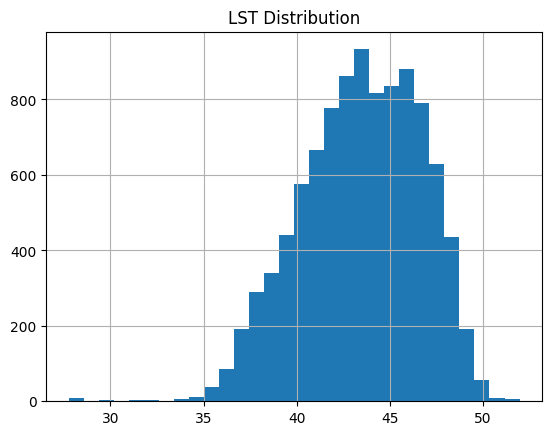

In [10]:
df["LST"].hist(
    bins=30
)

plt.title("LST Distribution")
plt.show()

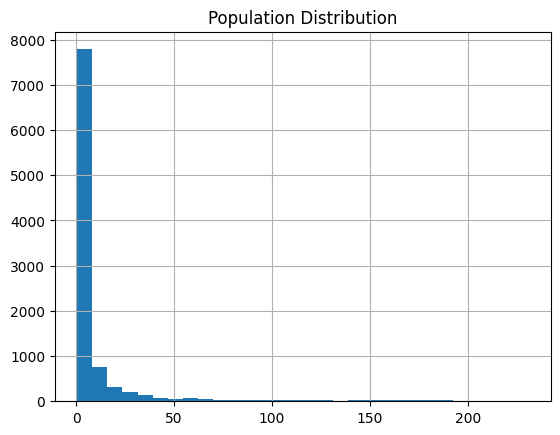

In [11]:
df["Population"].hist(
    bins=30
)

plt.title("Population Distribution")
plt.show()

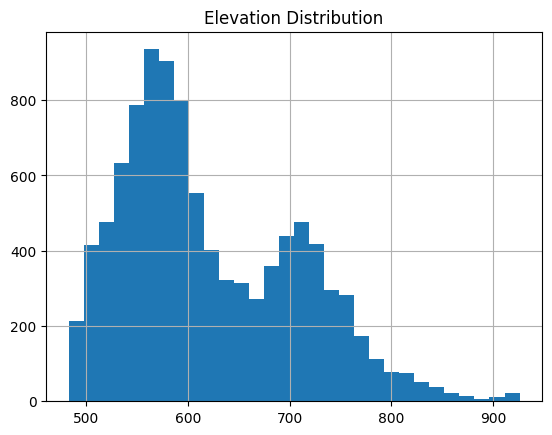

In [12]:
df["Elevation"].hist(
    bins=30
)

plt.title("Elevation Distribution")
plt.show()

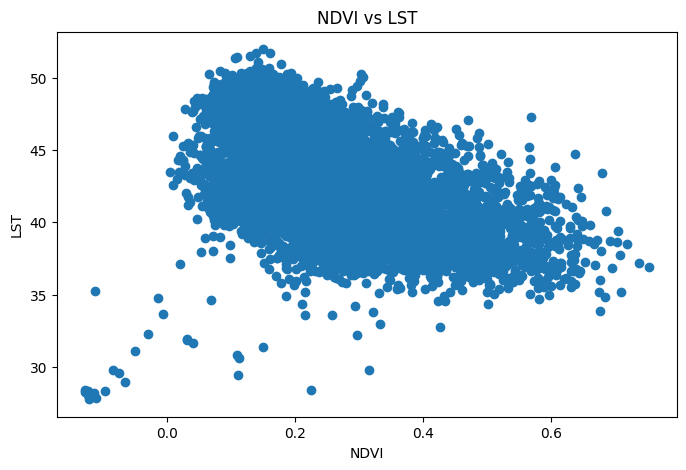

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["NDVI"],
    df["LST"]
)

plt.xlabel("NDVI")
plt.ylabel("LST")

plt.title("NDVI vs LST")

plt.show()

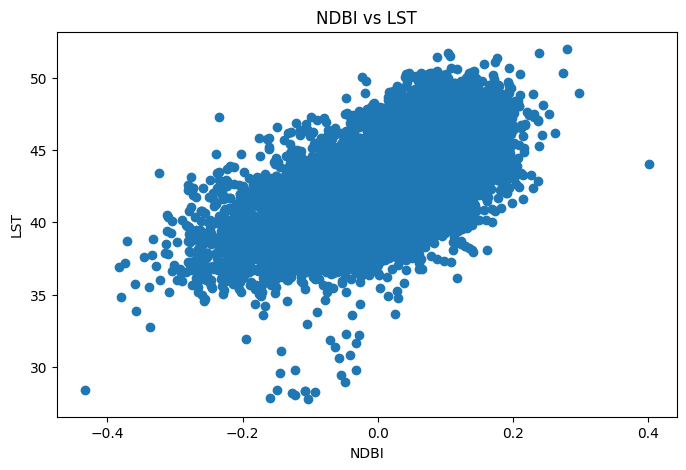

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["NDBI"],
    df["LST"]
)

plt.xlabel("NDBI")
plt.ylabel("LST")

plt.title("NDBI vs LST")

plt.show()

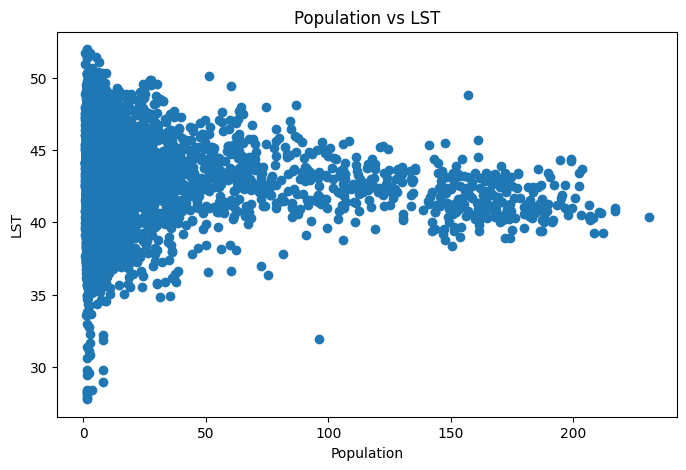

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Population"],
    df["LST"]
)

plt.xlabel("Population")
plt.ylabel("LST")

plt.title("Population vs LST")

plt.show()

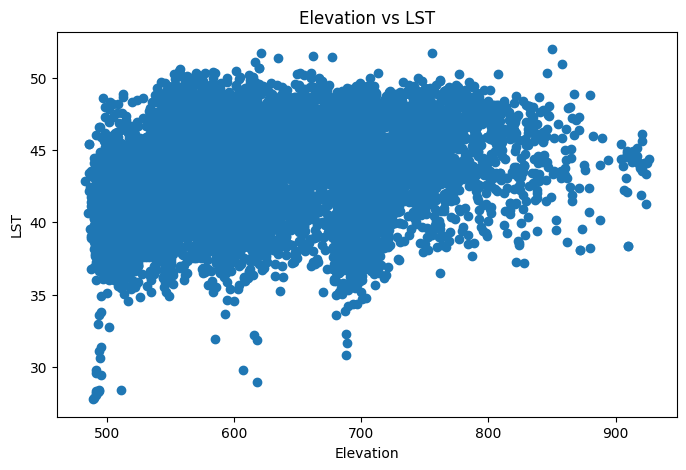

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Elevation"],
    df["LST"]
)

plt.xlabel("Elevation")
plt.ylabel("LST")

plt.title("Elevation vs LST")

plt.show()

In [3]:
lst_correlation = df.corr(numeric_only=True)["LST"].sort_values(
    ascending=False
)

print(lst_correlation)

LST           1.000000
NDBI          0.654087
Longitude     0.322742
Elevation     0.272437
Latitude      0.064604
Population   -0.105668
NDVI         -0.530768
Name: LST, dtype: float64


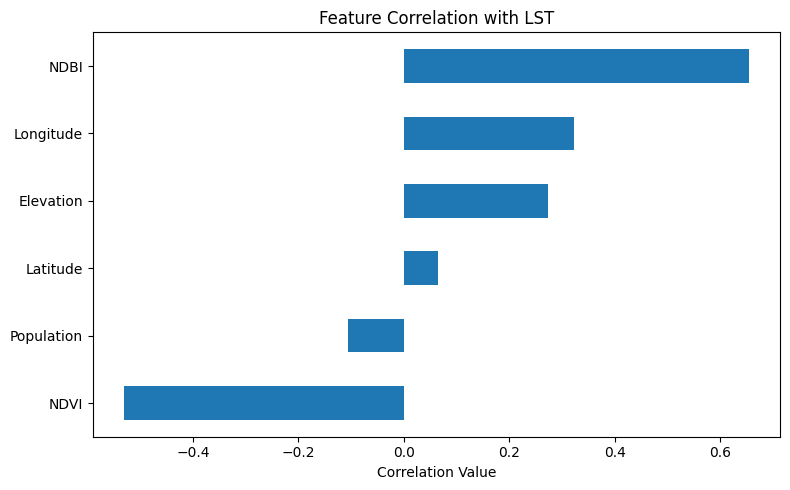

In [4]:
plt.figure(figsize=(8, 5))

lst_correlation.drop("LST").sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with LST")
plt.xlabel("Correlation Value")

plt.tight_layout()
plt.show()

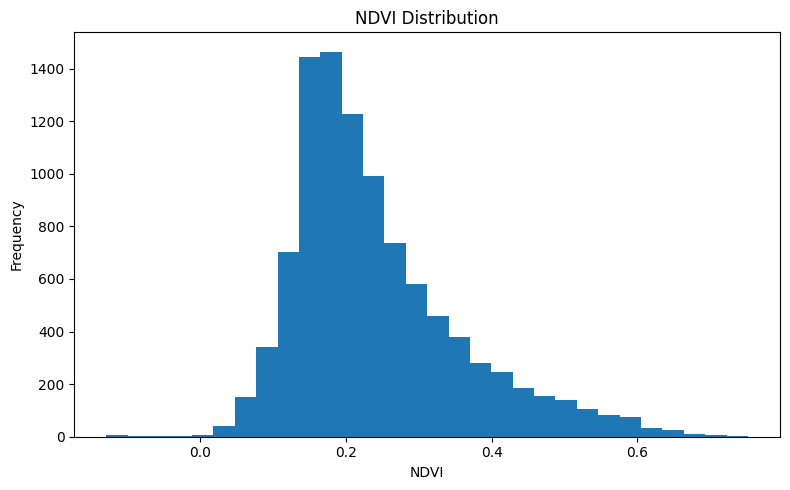

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(df["NDVI"], bins=30)

plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.title("NDVI Distribution")

plt.tight_layout()
plt.show()

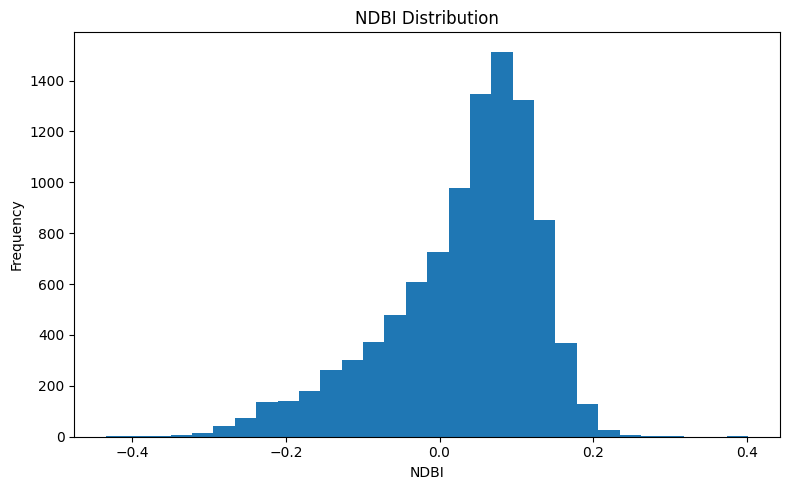

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df["NDBI"], bins=30)

plt.xlabel("NDBI")
plt.ylabel("Frequency")
plt.title("NDBI Distribution")

plt.tight_layout()
plt.show()

In [7]:
def heat_category(lst):
    if lst < 35:
        return "Low"
    elif lst < 40:
        return "Moderate"
    elif lst < 45:
        return "High"
    else:
        return "Very High"

df["Heat_Category"] = df["LST"].apply(heat_category)

print(df["Heat_Category"].value_counts())

Heat_Category
High         4842
Very High    3539
Moderate     1470
Low            42
Name: count, dtype: int64


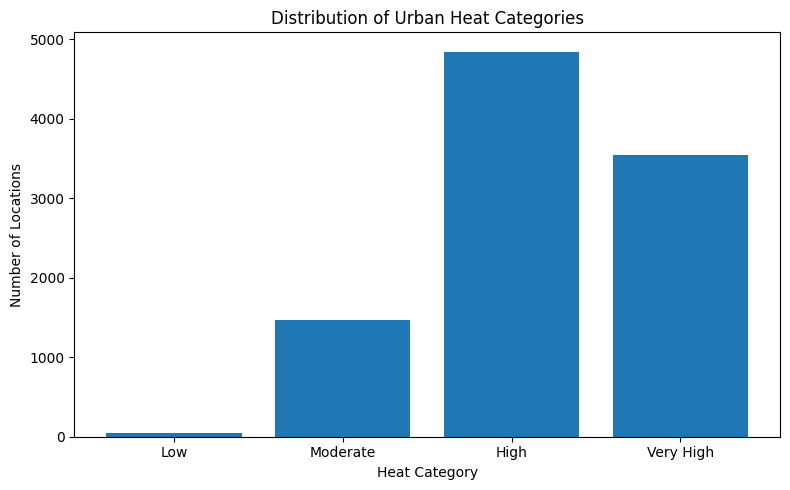

In [9]:
heat_counts = df["Heat_Category"].value_counts()

heat_counts = heat_counts.reindex(
    ["Low", "Moderate", "High", "Very High"],
    fill_value=0
)

plt.figure(figsize=(8, 5))

plt.bar(
    heat_counts.index,
    heat_counts.values
)

plt.xlabel("Heat Category")
plt.ylabel("Number of Locations")
plt.title("Distribution of Urban Heat Categories")

plt.tight_layout()
plt.show()

In [10]:
heat_summary = df.groupby("Heat_Category")["LST"].agg(
    ["count", "mean", "min", "max"]
)

heat_summary = heat_summary.reindex(
    ["Low", "Moderate", "High", "Very High"]
)

heat_summary

,count,mean,min,max
Heat_Category,,,,
Low,42,31.783368,27.762190,34.963958
Moderate,1470,38.393385,35.051118,39.996992
High,4842,42.654137,40.000411,44.999265
Very High,3539,46.815819,45.002683,51.956644


In [11]:
df.to_csv(
    "../data/processed/eda_uhi_v2_with_heat_category.csv",
    index=False
)

print("EDA dataset with Heat_Category saved successfully.")

EDA dataset with Heat_Category saved successfully.
